##Import Modules

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
import pandas as pd
import kagglehub
from tqdm import tqdm
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score
import cv2
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras import backend as K

##Load the dataset

In [2]:
path = kagglehub.dataset_download("nikhilroxtomar/brain-tumor-segmentation")
print("Contents of the dataset folder:", os.listdir(path))

Contents of the dataset folder: ['images', 'masks']


##Preprocessing


In [3]:

def load_train_data(path):
    # Define subdirectories
    images_dir = os.path.join(path, 'images')
    masks_dir = os.path.join(path, 'masks')

    images = [os.path.join(images_dir, filename) for filename in os.listdir(images_dir)]
    masks = [os.path.join(masks_dir, filename) for filename in os.listdir(masks_dir)]

    images.sort()
    masks.sort()

    #split the dataset into 60 training 20 testing and 20 validating
    train_x, val_x = train_test_split(images, test_size=0.2, random_state=42)
    train_y, val_y = train_test_split(masks, test_size=0.2, random_state=42)

    train_x, test_x = train_test_split(train_x, test_size=0.2, random_state=42)
    train_y, test_y = train_test_split(train_y, test_size=0.2, random_state=42)

    return train_x, train_y, val_x, val_y, test_x, test_y




In [4]:
def image_refine(imagep):
    image = tf.io.read_file(imagep)
    #decode as a 3-channel RGB image
    image = tf.image.decode_png(image, channels=3)
    #resize the image
    image = tf.image.resize(image, (256, 256))
    #normalize the image to [0, 1] and ensure it is float
    image = tf.cast(image, tf.float32) / 255.0
    return image

def mask_refine(maskp):
    mask = tf.io.read_file(maskp)
    #decode as a single-channel grayscale image
    mask = tf.image.decode_png(mask, channels=1)
    #resize the mask
    mask = tf.image.resize(mask, (256, 256))
    #convert mask to integer labels (zero-based)
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.expand_dims(mask, axis=-1)  # Shape: (256, 256, 1)

    return mask


In [5]:
def preprocess(image_path, mask_path):
    image = image_refine(image_path)
    mask = mask_refine(mask_path)
    return image, mask

def create_dataset(image_paths, mask_paths, batch_size=16):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset


In [6]:
train_x, train_y, val_x, val_y, test_x, test_y = load_train_data(path)

batch_size = 16
train_dataset = create_dataset(train_x, train_y, batch_size)
val_dataset = create_dataset(val_x, val_y, batch_size)
test_dataset = create_dataset(test_x, test_y, batch_size)


##Data Visualization

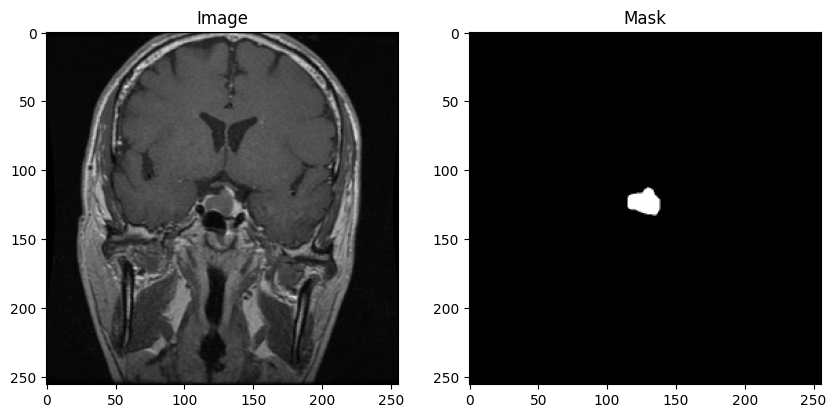

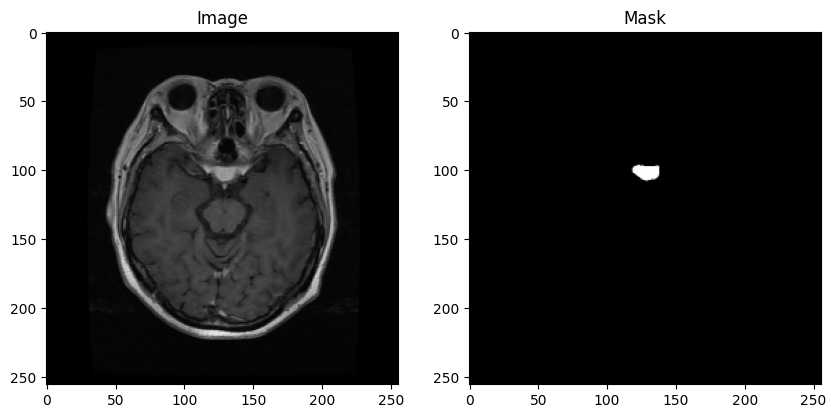

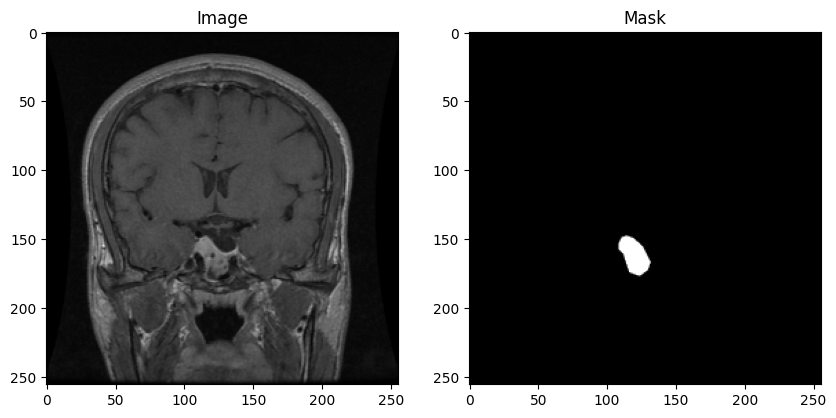

In [ ]:
def visualize_sample(dataset):
    for image, mask in dataset.take(1):
        for i in range(3):  #show 3 samples
            plt.figure(figsize=(10, 5))

            # Image
            plt.subplot(1, 2, 1)
            plt.imshow(image[i])
            plt.title("Image")

            # Mask
            plt.subplot(1, 2, 2)
            plt.imshow(tf.squeeze(mask[i]), cmap='gray')
            plt.title("Mask")

            plt.show()

#training samples
visualize_sample(train_dataset)


##Build the model



In [7]:
def build_convo_block(inputs, num_filters):
    x = Conv2D(num_filters, 3, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x

def encoder_block(inputs, num_filters):
    x = build_convo_block(inputs, num_filters)
    p = MaxPool2D((2, 2))(x)
    return x, p

def decoder_block(inputs, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, 2, strides=2, padding="same")(inputs)
    x = Concatenate()([x, skip_features])
    x = build_convo_block(x, num_filters)
    return x

In [8]:
def build_unet(input_shape):
    inputs = Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = build_convo_block(p4, 1024)

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = Model(inputs, outputs, name="UNET")
    return model


##Train model

In [9]:
smooth = 1e-15
def dice_coef(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)
    y_true = tf.keras.layers.Flatten()(y_true)
    y_pred = tf.keras.layers.Flatten()(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

In [10]:
input_shape = (256, 256, 3)
lr = 1e-4

model = build_unet(input_shape)
model.compile(optimizer=Adam(lr), loss=dice_loss , metrics=[dice_coef])

if not os.path.exists("files"):
    os.makedirs("files")

model_path = os.path.join("files", "model.h5")
csv_path = os.path.join("files", "log.csv")


callbacks = [
        ModelCheckpoint(model_path, verbose=1, save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-7, verbose=1),
        CSVLogger(csv_path),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=False),
    ]


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks= callbacks
)


##Test model

In [ ]:
def evaluate_and_save_results_tf(model, test_x, test_y, output_dir="results", image_size=(256, 256)):

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    scores = []

    for img_path, mask_path in tqdm(zip(test_x, test_y), total=len(test_x)):
        name = os.path.basename(img_path)

        #read and preprocess the test image
        image = tf.io.read_file(img_path)
        image = tf.io.decode_image(image, channels=3)
        image = tf.image.resize(image, image_size)
        image_norm = tf.cast(image, tf.float32) / 255.0
        image_input = tf.expand_dims(image_norm, axis=0)

        #read and preprocess the mask
        mask = tf.io.read_file(mask_path)
        mask = tf.io.decode_image(mask, channels=1)
        mask = tf.image.resize(mask, image_size)
        mask = tf.squeeze(mask, axis=-1)

        #model prediction
        pred = model(image_input, training=False)
        pred_binary = tf.cast(pred >= 0.5, tf.uint8)[0, ..., 0]

        image_uint8 = tf.cast(image, tf.uint8)
        mask_uint8 = tf.cast(mask, tf.uint8)
        pred_uint8 = pred_binary * 255

        combined = tf.concat([
            image_uint8,
            tf.ones([image_size[0], 10, 3], dtype=tf.uint8) * 255,
            tf.tile(tf.expand_dims(mask_uint8, axis=-1), [1, 1, 3]),
            tf.ones([image_size[0], 10, 3], dtype=tf.uint8) * 255,
            tf.tile(tf.expand_dims(pred_uint8, axis=-1), [1, 1, 3])
        ], axis=1)
        combined_np = combined.numpy()
        save_path = os.path.join(output_dir, name)
        cv2.imwrite(save_path, combined_np)


        mask_flat = tf.reshape(mask > 127, [-1]).numpy().astype(np.int32)
        pred_flat = tf.reshape(pred_binary, [-1]).numpy()
        f1 = f1_score(mask_flat, pred_flat, average="binary")
        jaccard = jaccard_score(mask_flat, pred_flat, average="binary")
        precision = precision_score(mask_flat, pred_flat, average="binary", zero_division=0)
        recall = recall_score(mask_flat, pred_flat, average="binary", zero_division=0)
        scores.append([name, f1, jaccard, precision, recall])

    #save metrics to CSV
    df = pd.DataFrame(scores, columns=["Image", "F1", "Jaccard", "Precision", "Recall"])
    csv_path = os.path.join(output_dir, "metrics.csv")
    df.to_csv(csv_path, index=False)

    #print metrics
    mean_scores = np.mean(df.iloc[:, 1:].values, axis=0)
    print(f"F1: {mean_scores[0]:.5f}")
    print(f"Jaccard: {mean_scores[1]:.5f}")
    print(f"Precision: {mean_scores[2]:.5f}")
    print(f"Recall: {mean_scores[3]:.5f}")

    print(f"Results and metrics saved in: {output_dir}")


evaluate_and_save_results_tf(model, test_x, test_y, output_dir="results")
